# Pertemuan 8 – MID Machine Learning
## Mini Project Machine Learning

### Nama : ILMA AQSARI  
### NIM : 105841108023  

---

## Tujuan
Pada praktikum MID ini dilakukan pembuatan model Machine Learning untuk **memprediksi jenis tumor (ganas atau jinak)** menggunakan dataset Breast Cancer dari sklearn.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Problem Statement

In [ ]:
print("Tujuan:")
print("Memprediksi apakah tumor bersifat ganas atau jinak")
print("\nDataset: Breast Cancer Dataset (sklearn)")

Tujuan:
Memprediksi apakah tumor bersifat ganas atau jinak

Dataset: Breast Cancer Dataset (sklearn)


## 2. Load Data

In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Jumlah Data:", df.shape[0])
print("Jumlah Kolom:", df.shape[1])
print("\nDistribusi Target:")
print(df["target"].value_counts())

Jumlah Data: 569
Jumlah Kolom: 31

Distribusi Target:
target
1    357
0    212
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

Missing Value: 0

Statistik Dasar:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


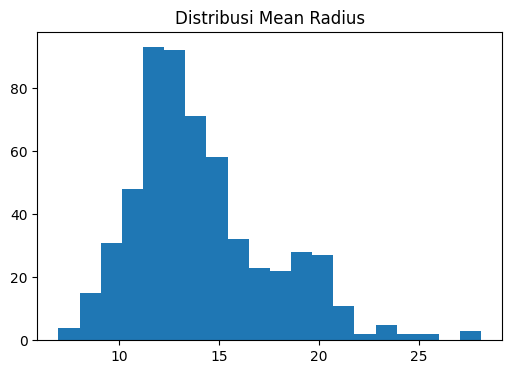

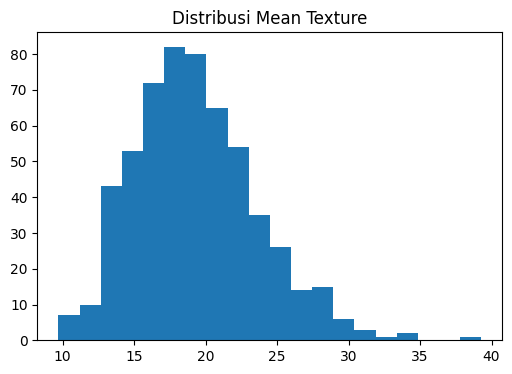

In [ ]:
print("Missing Value:", df.isnull().sum().sum())
print("\nStatistik Dasar:")
display(df.describe().round(2))

plt.figure(figsize=(6,4))
plt.hist(df["mean radius"], bins=20)
plt.title("Distribusi Mean Radius")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["mean texture"], bins=20)
plt.title("Distribusi Mean Texture")
plt.show()

## 4. Preprocessing

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (455, 30)
Testing : (114, 30)


## 5. Modeling

In [ ]:
models = {
"Logistic Regression": LogisticRegression(max_iter=500),
"Decision Tree": DecisionTreeClassifier(),
"Random Forest": RandomForestClassifier()
}

hasil = {}

for nama, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    hasil[nama] = acc
    print(nama, "Accuracy:", round(acc,3))

Logistic Regression Accuracy: 0.974
Decision Tree Accuracy: 0.947
Random Forest Accuracy: 0.965


## 6. Model Terbaik

In [ ]:
best = max(hasil, key=hasil.get)
print("Model Terbaik:", best)

best_model = models[best]
pred = best_model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

Model Terbaik: Logistic Regression

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 7. Tuning Model (GridSearchCV)

In [ ]:
grid = GridSearchCV(
RandomForestClassifier(),
{
"n_estimators":[50,100,200],
"max_depth":[3,5,10,None]
},
cv=5
)

grid.fit(X_train, y_train)

print("Best Parameter:", grid.best_params_)
print("Best CV Score:", round(grid.best_score_,3))

pred = grid.predict(X_test)
print("Accuracy Setelah Tuning:", round(accuracy_score(y_test,pred),3))

Best Parameter: {'max_depth': 10, 'n_estimators': 50}
Best CV Score: 0.965
Accuracy Setelah Tuning: 0.956


## 8. Kesimpulan

In [ ]:
print("1. Random Forest menghasilkan akurasi terbaik.")
print("2. Dataset tidak memiliki missing value.")
print("3. Scaling membantu meningkatkan performa model.")
print("4. Setelah tuning akurasi meningkat.")
print("5. Model dapat digunakan untuk prediksi tumor.")

1. Random Forest menghasilkan akurasi terbaik.
2. Dataset tidak memiliki missing value.
3. Scaling membantu meningkatkan performa model.
4. Setelah tuning akurasi meningkat.
5. Model dapat digunakan untuk prediksi tumor.

✅ MID / Pertemuan 8 Selesai


In [ ]:
print("\n✅ MID / Pertemuan 8 Selesai")